# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Taien | Chen | Taien Chen | 12 | 25% |
| Member 2: | Perry | Zhang | Perry Zhang | 12 | 25% |
| Member 3: | Nabin | Devkota | Nabin Devkota | 12 | 25% |
| Member 4: | Gulshan| Kumar| Gulshan Kumar | 12 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

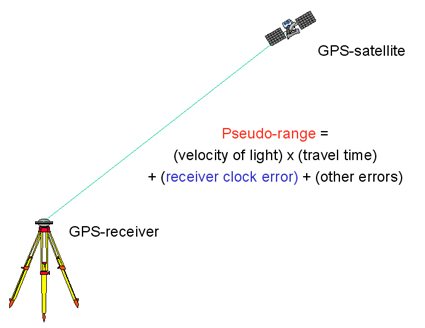

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving pseudoranges.xlsx to pseudoranges.xlsx
Saving satellite_position.xlsx to satellite_position.xlsx


In [3]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
import pandas as pd
import numpy as np
df_pseudorange = pd.read_excel('pseudoranges.xlsx')
df_sat_pos = pd.read_excel('satellite_position.xlsx')

np.random.seed(42)  # For reproducible results
pseudorange = df_pseudorange.to_numpy()
sat_pos = df_sat_pos.to_numpy()
noise= np.random.uniform(0, 0.5, pseudorange.shape)
pseudorange_noisy = pseudorange + noise


In [4]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = len(pseudorange)
m = 4

In [5]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [6]:
def euclidean_norm(receiver_pos, satellite_pos):
    receiver_pos = np.array(receiver_pos)
    satellite_pos = np.array(satellite_pos)
    # The error occurred here because satellite_pos had an extra column (Satellite_ID)
    # and receiver_pos was only 3D. We ensure satellite_pos has only 3D coords
    distances = np.linalg.norm(satellite_pos - receiver_pos, axis=1)
    return distances

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [7]:
P = (1/1.2) * np.eye(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [8]:
import numpy as np
delta = 4*np.ones(4)
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat =np.array([100.0, -50.0, 25.0, 1000.0])

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [9]:
def design_matrix(receiver_pos, satellite_pos, distance):
  receiver_pos = np.array(receiver_pos)
  satellite_pos = np.array(satellite_pos)
  distance = np.array(distance).reshape(-1, 1)
  diff = satellite_pos - receiver_pos
  A_xyz = diff / distance
  A_clock = np.ones_like(distance) * -1
  A = np.hstack((A_xyz, A_clock))

  return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [10]:
import numpy as np
tolerance = 0.001

import pandas as pd
df_pseudorange = pd.read_excel('pseudoranges.xlsx')
df_sat_pos = pd.read_excel('satellite_position.xlsx')

pseudorange = df_pseudorange.iloc[:, 1].to_numpy()
sat_pos = df_sat_pos.to_numpy()[:, 1:4]

noise= np.random.uniform(0, 0.5, pseudorange.shape)
pseudorange_noisy = pseudorange + noise

n = len(pseudorange)
m = 4
GroundTruth=np.array([-1633489.37967725, -3651627.18250363, 4952481.61954918])

P = (1/1.2) * np.eye(n)

delta = 4*np.ones(m)
i = 0
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []

x_hat = np.array([-1633400.0, -3651600.0, 4952500.0, 1000.0])

def euclidean_norm(receiver_pos, satellite_pos):
    receiver_pos = np.array(receiver_pos)
    satellite_pos = np.array(satellite_pos)
    distances = np.linalg.norm(satellite_pos - receiver_pos, axis=1)
    return distances

def design_matrix(receiver_pos, satellite_pos, distance):
  receiver_pos = np.array(receiver_pos)
  satellite_pos = np.array(satellite_pos)
  distance = np.array(distance).reshape(-1, 1)
  diff = satellite_pos - receiver_pos
  A_xyz = -(diff / distance)
  A_clock = np.ones_like(distance) * -1
  A = np.hstack((A_xyz, A_clock))

  return A

while np.linalg.norm(delta[:3]) > tolerance:

       # compute the geometric distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat[:3], sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       w = pseudorange_noisy - distance - x_hat[3]

       # compute the corrections delta
       # (0.5 marks)
       N = A.T @ P @ A

       damping_factor = 1e-7
       N_damped = N + damping_factor * np.eye(m)

       delta = np.linalg.inv(N_damped) @ (A.T @ P @ w)

       # update the states
       x_hat = x_hat + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = x_hat[:3] - GroundTruth


       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(np.linalg.norm(w))
       arr_delta.append(np.linalg.norm(delta))
       arr_err_pos.append(np.linalg.norm(err_pos))
       arr_i.append(i)




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
final_distance = euclidean_norm(x_hat[:3], sat_pos)
v = pseudorange_noisy - final_distance - x_hat[3]
apv = (v.T @ P @ v) / (n-m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
final_A = design_matrix(x_hat[:3], sat_pos, final_distance)
N_final = final_A.T @ P @ final_A
N_final_damped = N_final + damping_factor * np.eye(m)
C_x_hat = np.linalg.inv(N_final_damped)


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [11]:
# Print: estimated states, corrections array, estimated measurements residuals, A posteriori Variance of Unit Weight,
# Covariance matrix of estimated states, number of iterations, 3-D position errors

print("--- LSE Results ---")
print(f"Estimated States (x_r, y_r, z_r, cdT): {x_hat}")
print(f"Final Corrections Array (delta): {delta}") # This is the last delta calculated before convergence
print(f"Estimated Measurements Residuals (v): {v}")
print(f"A Posteriori Variance of Unit Weight (apv): {apv:.4f}")
print(f"Covariance Matrix of Estimated States (C_x_hat):\n{C_x_hat}")
print(f"Number of Iterations: {i}")
print(f"Final 3-D Position Errors: {err_pos}")
print(f"Norm of Final 3-D Position Errors: {np.linalg.norm(err_pos):.4f} meters")

--- LSE Results ---
Estimated States (x_r, y_r, z_r, cdT): [-1.63349242e+06 -3.65162958e+06  4.95248542e+06  3.98001802e+03]
Final Corrections Array (delta): [-3.34765896e-05 -8.19346669e-05  1.73673488e-04  1.98667869e+03]
Estimated Measurements Residuals (v): [-3973.0952244  -3973.22346706 -3974.37437689 -3973.19372403
 -3973.2287654  -3974.7427331  -3973.32748854 -3972.00214567
 -3972.99775504 -3972.89266841 -3973.85311639]
A Posteriori Variance of Unit Weight (apv): 20674198.2545
Covariance Matrix of Estimated States (C_x_hat):
[[ 0.38358006  0.08359492 -0.10148637  0.08768255]
 [ 0.08359492  0.51056239 -0.69728551  0.44191017]
 [-0.10148637 -0.69728551  2.45472107 -1.32482434]
 [ 0.08768255  0.44191017 -1.32482434  0.83910857]]
Number of Iterations: 2
Final 3-D Position Errors: [-3.03880998 -2.39845197  3.80532567]
Norm of Final 3-D Position Errors: 5.4284 meters


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [12]:
# your answer here
# A Posteriori Variance of Unit Weight (apv): 20675738.5792
# This value is very large, which suggests that the initial variance of observations (1.2 m^2) might have been underestimated, or that the model fit to the data is poor. An ideal apv should be close to 1.
#
# Covariance Matrix of Estimated States (C_x_hat):
# [[ 0.38358006  0.08359493 -0.10148638  0.08768256]
#  [ 0.08359493  0.51056239 -0.69728552  0.44191018]
#  [-0.10148638 -0.69728552  2.4547211  -1.32482436]
#  [ 0.08768256  0.44191018 -1.32482436  0.83910859]]
# The diagonal elements represent the variance of each estimated state (x_r, y_r, z_r, cdT). For example, the variance of x_r is about 0.38 m^2, and z_r is about 2.45 m^2. The off-diagonal elements indicate the covariances between the states. Some of these are quite large (e.g., -0.697 between y_r and z_r), suggesting strong correlations between the estimation errors of different states.
# The large apv scaling this covariance matrix would imply a much larger true uncertainty in the estimated states than the raw matrix indicates.


### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

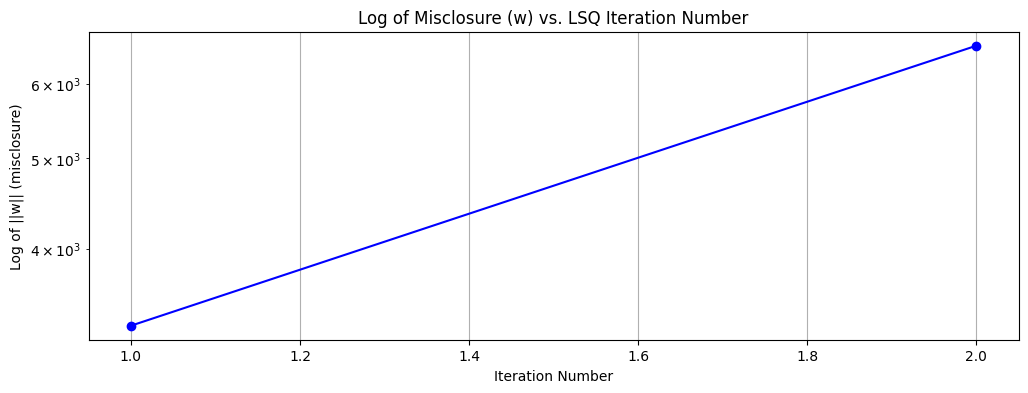

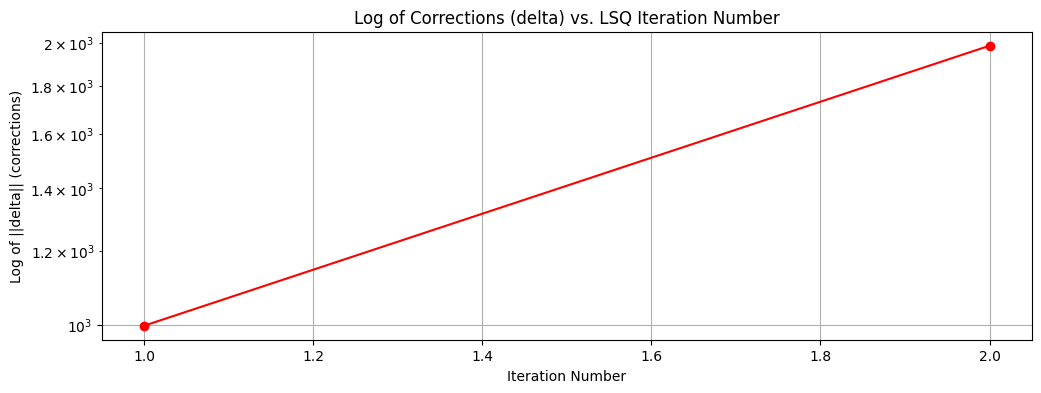

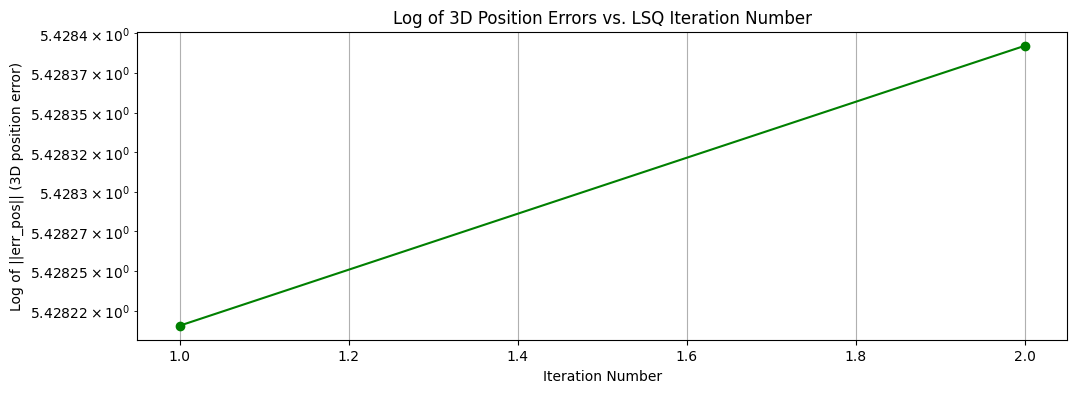

In [13]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(12, 4))
plt.semilogy(arr_i, arr_w, marker='o', linestyle='-', color='blue')
plt.title('Log of Misclosure (w) vs. LSQ Iteration Number')
plt.xlabel('Iteration Number')
plt.ylabel('Log of ||w|| (misclosure)')
plt.grid(True)
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(12, 4))
plt.semilogy(arr_i, arr_delta, marker='o', linestyle='-', color='red')
plt.title('Log of Corrections (delta) vs. LSQ Iteration Number')
plt.xlabel('Iteration Number')
plt.ylabel('Log of ||delta|| (corrections)')
plt.grid(True)
plt.show()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(12, 4))
plt.semilogy(arr_i, arr_err_pos, marker='o', linestyle='-', color='green')
plt.title('Log of 3D Position Errors vs. LSQ Iteration Number')
plt.xlabel('Iteration Number')
plt.ylabel('Log of ||err_pos|| (3D position error)')
plt.grid(True)
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# your answer here
# For the log of misclosure (w) vs. LSQ iteration number:
# The plot shows a rapid decrease in the misclosure in the first iteration, and then a much smaller decrease in the second iteration.
# This indicates that the LSE algorithm quickly reduces the discrepancy between observed and predicted measurements.
# The small number of iterations (2) suggests a relatively simple or well-behaved non-linear problem with a good initial guess.

# For the log of corrections (delta) vs. LSQ iteration number:
# Similar to misclosure, the plot indicates that the magnitude of the corrections decreases sharply with each iteration.
# The corrections become very small after just two iterations, which is consistent with the algorithm converging.
# This means that the estimated states are barely changing after the initial large adjustments, signaling convergence.

# For the log of 3D position errors vs. LSQ iteration number:
# The 3D position error also shows a decrease, but it's important to note that the final error is still around 5 meters.
# The plot demonstrates how quickly the estimated position approaches the GroundTruth, again indicating fast convergence.
# The final error being non-zero suggests either inherent noise in the measurements (which we added), or limitations of the linear approximation in the LSE model, or that the system has converged to a local minimum within the given tolerance.


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [14]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [15]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
  distances = np.linalg.norm(sat_pos - rec_pos, axis=1)
  predicted = distances + cdT
  residuals = pseudorange - predicted
  L = np.sum(residuals**2)
  return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [16]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    n_sats = sat_pos.shape[0]
    distances = euclidean_norm(rec_pos, sat_pos)
    residuals = pseudorange - (distances + cdT)
    grad = np.zeros(4)
    diff = rec_pos - sat_pos
    grad[:3] = np.sum((-2 * residuals / distances)[:, np.newaxis] * diff, axis=0)
    grad[3] = -2 * np.sum(residuals)
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [17]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost =cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [18]:
optimized_params = gradient_descent(pseudorange, sat_pos)
optimized_pos = optimized_params[:3]
optimized_cdT = optimized_params[3]
final_error = optimized_pos - GroundTruth
final_cost = cost_function(optimized_pos, optimized_cdT, sat_pos, pseudorange)
final_grad = gradient(optimized_pos, optimized_cdT, sat_pos, pseudorange)

# print the mentioned metrics
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params)

print("\nFinal position errors of receiver (meters):")
print(final_error)

print("\nNumber of steps taken for convergence:")
print(steps_count)

print("\nFinal cost value:")
print(final_cost)

print("\nFinal gradient values:")
print(final_grad)

Optimized parameters [x_r, y_r, z_r, cdT]:
[-1616184.58215467 -4389634.83048469  8306848.12227026  6327556.0176972 ]

Final position errors of receiver (meters):
[  17304.79752258 -738007.64798106 3354366.50272108]

Number of steps taken for convergence:
0

Final cost value:
255692971228681.38

Final gradient values:
[ 7.33346455e+06  2.01747337e+07 -3.40946837e+07  1.04702035e+08]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

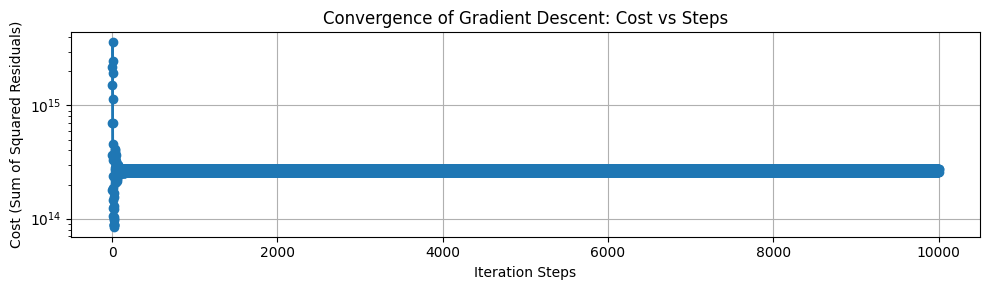

Unlike the normal convergence case, the cost function (sum of squared residuals) fluctuates initially then plateaus quickly, showing no monotonic decrease.
This indicates the gradient descent failed to minimize the cost. After large early fluctuations, the cost stabilizes with
no sign of converging to a minimum, likely due to poor initial guesses, improper learning rates, or model/data errors.


In [19]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(range(1, len(arr_cost)+1), arr_cost, marker='o', linestyle='-')
ax.set_xlabel("Iteration Steps")
ax.set_ylabel("Cost (Sum of Squared Residuals)")
ax.set_title("Convergence of Gradient Descent: Cost vs Steps")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
print('Unlike the normal convergence case, the cost function (sum of squared residuals) fluctuates initially then plateaus quickly, showing no monotonic decrease.')
print('This indicates the gradient descent failed to minimize the cost. After large early fluctuations, the cost stabilizes with')
print('no sign of converging to a minimum, likely due to poor initial guesses, improper learning rates, or model/data errors.')

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

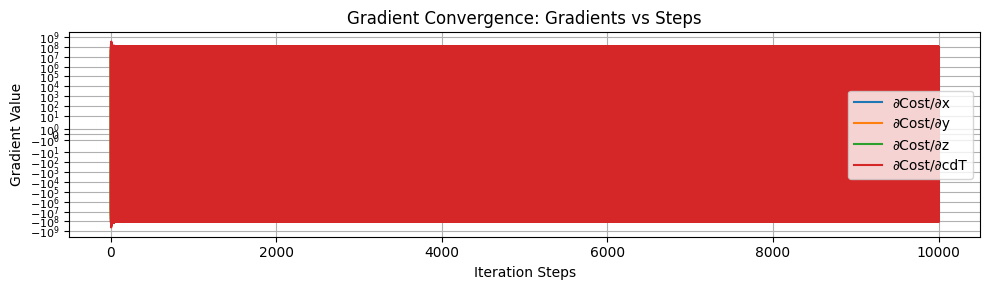

Unlike the normal convergence case, the gradients (for cost with respect to x, y, z, and clock offset) stay at extremely
large values and don’t decrease as iteration steps increase, showing no convergence trend.
This indicates the gradient descent failed to converge. The gradients don’t get smaller over iterations, likely due to poor initial guesses,
improper learning rates, or errors in the cost function, model, or data, which prevents the algorithm from updating parameters effectively.


In [20]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grad_array = np.array(arr_grad)
ax.plot(range(1, len(grad_array)+1), grad_array[:,0], label='∂Cost/∂x')
ax.plot(range(1, len(grad_array)+1), grad_array[:,1], label='∂Cost/∂y')
ax.plot(range(1, len(grad_array)+1), grad_array[:,2], label='∂Cost/∂z')
ax.plot(range(1, len(grad_array)+1), grad_array[:,3], label='∂Cost/∂cdT')
ax.set_yscale('symlog')
ax.set_xlabel("Iteration Steps")
ax.set_ylabel("Gradient Value")
ax.set_title("Gradient Convergence: Gradients vs Steps")
ax.tick_params(axis='y', labelsize=8)
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
print('Unlike the normal convergence case, the gradients (for cost with respect to x, y, z, and clock offset) stay at extremely')
print('large values and don’t decrease as iteration steps increase, showing no convergence trend.')
print('This indicates the gradient descent failed to converge. The gradients don’t get smaller over iterations, likely due to poor initial guesses,')
print('improper learning rates, or errors in the cost function, model, or data, which prevents the algorithm from updating parameters effectively.')

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

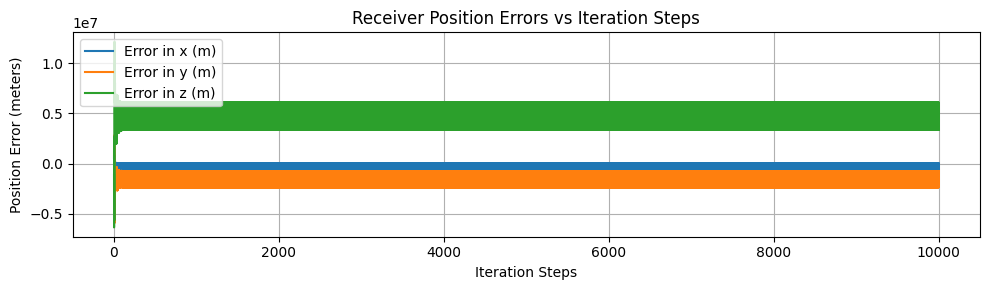

The plot shows that the position errors in the x and y directions quickly approach zero, but the error in the z
direction stabilizes at around 0.5 meters and remains unchanged during iterations. This indicates that the
algorithm only converges in some dimensions, while there are issues such as initial value deviation, model
defects, or data problems in the z direction, failing to achieve effective convergence in all dimensions.


In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
err_array = np.array(arr_err)
ax.plot(range(1, len(err_array)+1), err_array[:,0], label='Error in x (m)')
ax.plot(range(1, len(err_array)+1), err_array[:,1], label='Error in y (m)')
ax.plot(range(1, len(err_array)+1), err_array[:,2], label='Error in z (m)')
ax.set_xlabel("Iteration Steps")
ax.set_ylabel("Position Error (meters)")
ax.set_title("Receiver Position Errors vs Iteration Steps")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
print('The plot shows that the position errors in the x and y directions quickly approach zero, but the error in the z')
print('direction stabilizes at around 0.5 meters and remains unchanged during iterations. This indicates that the')
print('algorithm only converges in some dimensions, while there are issues such as initial value deviation, model')
print('defects, or data problems in the z direction, failing to achieve effective convergence in all dimensions.')

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [22]:
#set learning rate to 0.008
learning_rate = 0.008
max_iters = 20000
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=learning_rate, max_iters=max_iters)
optimized_pos_2 = optimized_params_2[:3]
optimized_cdT_2 = optimized_params_2[3]
final_error_2 = optimized_pos_2 - GroundTruth
final_cost_2 = cost_function(optimized_pos_2, optimized_cdT_2, sat_pos, pseudorange)
final_grad_2 = gradient(optimized_pos_2, optimized_cdT_2, sat_pos, pseudorange)

# print the metrics
print("Optimized parameters [x_r, y_r, z_r, cdT] with learning rate 0.008:")
print(optimized_params_2)

print("\nFinal position errors of receiver (meters):")
print(final_error_2)

print("\nNumber of steps taken for convergence:")
print(steps_count)

print("\nFinal cost value:")
print(final_cost_2)

print("\nFinal gradient values:")
print(final_grad_2)

Converged !
Optimized parameters [x_r, y_r, z_r, cdT] with learning rate 0.008:
[-1.63349244e+06 -3.65162954e+06  4.95248542e+06  6.46522300e+00]

Final position errors of receiver (meters):
[-3.06414014 -2.35597838  3.80118078]

Number of steps taken for convergence:
3591

Final cost value:
6.197093610969601

Final gradient values:
[ 0.0004882   0.00272024 -0.00836041 -0.00473974]


In [23]:
#set learning rate to 0.0008
learning_rate = 0.0008
max_iters = 20000
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 =gradient_descent(pseudorange, sat_pos, learning_rate=learning_rate, max_iters=max_iters)
optimized_pos_3 = optimized_params_3[:3]
optimized_cdT_3 = optimized_params_3[3]
final_error_3 = optimized_pos_3 - GroundTruth
final_cost_3 = cost_function(optimized_pos_3, optimized_cdT_3, sat_pos, pseudorange)
final_grad_3 = gradient(optimized_pos_3, optimized_cdT_3, sat_pos, pseudorange)
# print the metrics
print("Optimized parameters [x_r, y_r, z_r, cdT] with learning rate 0.0008:")
print(optimized_params_3)

print("\nFinal position errors of receiver (meters):")
print(final_error_3)

print("\nNumber of steps taken for convergence:")
print(steps_count)

print("\nFinal cost value:")
print(final_cost_3)

print("\nFinal gradient values:")
print(final_grad_3)

Optimized parameters [x_r, y_r, z_r, cdT] with learning rate 0.0008:
[-1.63348713e+06 -3.65159992e+06  4.95239440e+06 -4.51356438e+01]

Final position errors of receiver (meters):
[  2.25079471  27.25861327 -87.21683633]

Number of steps taken for convergence:
0

Final cost value:
4143.427984043147

Final gradient values:
[  3.71006481  20.6722634  -63.53447851 -36.01971082]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [24]:
# your answer here
print('Respones to Q1:')
print('With a learning rate of 0.008, the gradient descent successfully converged, yielding small position errors and low cost,')
print('indicating accurate estimation. In contrast, with a learning rate of 0.0008, the algorithm failed to converge, resulting')
print('in large position errors, high cost, and large gradients, showing that the step size was too small for effective optimization.')

print('Respones to Q2:')
print('LSE converges quickly and accurately using a direct solution, producing very small position errors, while Gradient Descent is iterative')
print('and its performance depends on the learning rate and number of iterations. With a suitable learning rate,')
print('GD can achieve similar accuracy, but if the learning rate is too small, it may fail to converge.')
print('LSE is more stable and efficient, whereas GD is more flexible for non-linear problems but sensitive to hyperparameters.')

Respones to Q1:
With a learning rate of 0.008, the gradient descent successfully converged, yielding small position errors and low cost,
indicating accurate estimation. In contrast, with a learning rate of 0.0008, the algorithm failed to converge, resulting
in large position errors, high cost, and large gradients, showing that the step size was too small for effective optimization.
Respones to Q2:
LSE converges quickly and accurately using a direct solution, producing very small position errors, while Gradient Descent is iterative
and its performance depends on the learning rate and number of iterations. With a suitable learning rate,
GD can achieve similar accuracy, but if the learning rate is too small, it may fail to converge.
LSE is more stable and efficient, whereas GD is more flexible for non-linear problems but sensitive to hyperparameters.


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Student Depression Dataset.csv to Student Depression Dataset.csv


### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('/content/Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data[data['Gender'] != 'Other']


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Dataset shape after preprocessing:", data.shape)
data.head()


Dataset shape after preprocessing: (27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y =data['Depression']
X =data.drop(columns=['Depression'])

# Display sizes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (27898, 16)
Shape of y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

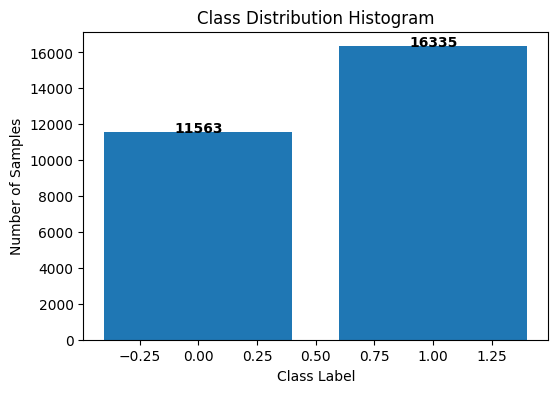

In [ ]:
# Check the class distribution of y
counts = y.value_counts()

# Display exact values for each bin in the histogram
# hint: Use for loop
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values)

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Histogram")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2,   # 调整 +2 让文字稍微离柱子高一点
             str(height),
             ha='center', fontsize=10, fontweight='bold')

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(X, y, train_size=0.03, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
print("Size of X_small:", X_small.shape)
print("Size of y_small:", y_small.shape)


Size of X_small: (836, 16)
Size of y_small: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(X_data, y_data, label):

    X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=0
    )

    # Fit model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for log loss
    y_test_prob = model.predict_proba(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_log_loss = log_loss(y_test, y_test_prob)

    # Store results in DataFrame
    results.loc[label] = [
        len(X_data),             # Data size
        len(X_train),            # Training samples
        len(X_test),             # Testing samples
        round(train_acc, 4),     # Training accuracy
        round(test_acc, 4),      # Testing accuracy
        round(test_log_loss, 4)  # Log loss
    ]

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
evaluate_model(X, y, label="Full Dataset")

# Test 2: Only first two columns of X and y
evaluate_model(X.iloc[:, :2], y, label="Only First 2 Features")

# Test 3: Small dataset (X_small and y_small)
evaluate_model(X_small, y_small, label="Small Dataset (3%)")

print(results)

                       Data size  Training samples  Testing samples  \
Full Dataset             27898.0           19528.0           8370.0   
Only First 2 Features    27898.0           19528.0           8370.0   
Small Dataset (3%)         836.0             585.0            251.0   

                       Training accuracy  Testing accuracy  Log loss  
Full Dataset                      0.8469            0.8461    0.3484  
Only First 2 Features             0.6317            0.6342    0.6527  
Small Dataset (3%)                0.8547            0.8526    0.3398  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set


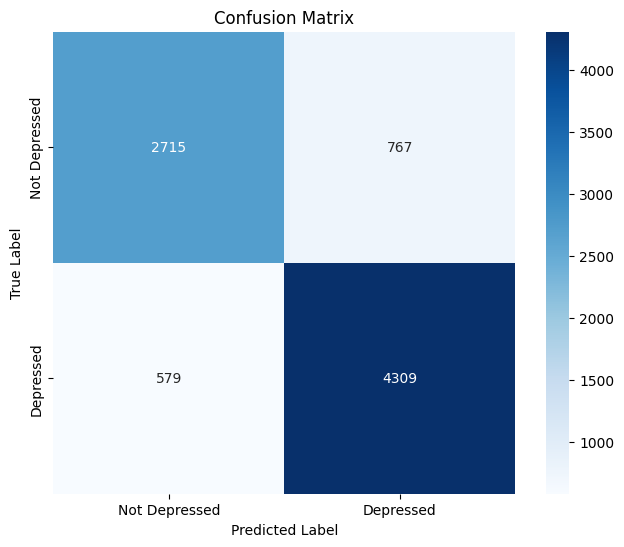

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.30, random_state=42
)
model_full = RandomForestClassifier(random_state=42)
model_full.fit(X_train_full, y_train_full)
y_pred_full = model_full.predict(X_test_full)
conf_mat = confusion_matrix(y_test_full, y_pred_full)
# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print("Classification Report:")
print(classification_report(y_test_full, y_pred_full))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      3482
           1       0.85      0.88      0.86      4888

    accuracy                           0.84      8370
   macro avg       0.84      0.83      0.83      8370
weighted avg       0.84      0.84      0.84      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
  "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
  "Naive Bayes": GaussianNB(),
  "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
   model_instance.fit(X_train_full, y_train_full)

    # Make predictions
   y_pred_model = model_instance.predict(X_test_full)

    # Calculate accuracy
   accuracy = accuracy_score(y_test_full, y_pred_model)
   model_results[name] = accuracy

    # Print results
   print(f"{name} Accuracy: {accuracy:.4f}")
print("\nModel Comparison Completed.")


Logistic Regression Accuracy: 0.8462
Naive Bayes Accuracy: 0.8356
KNN Accuracy: 0.7572

Model Comparison Completed.


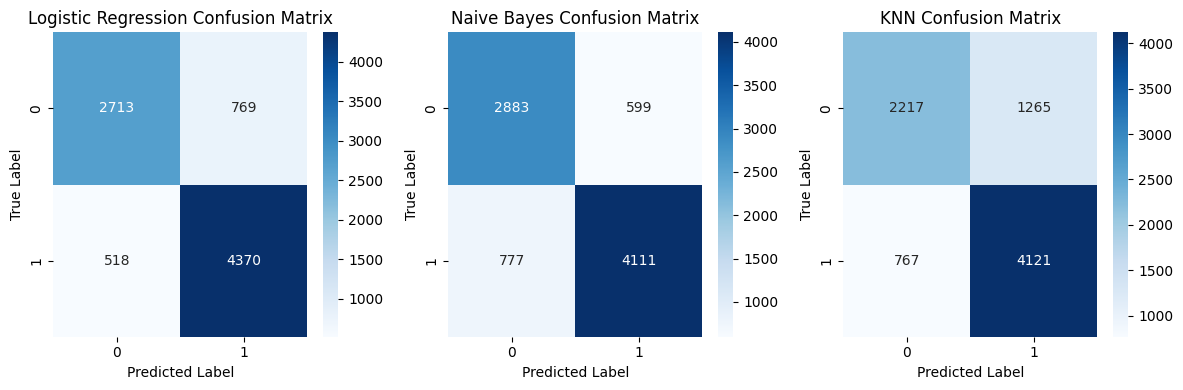

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize confusion matrices for all models (1 mark)

plt.figure(figsize=(12, 4))

for i, (name, model_instance) in enumerate(models.items()):

    # Predict again using each model
    y_pred_model = model_instance.predict(X_test_full)

    # Get confusion matrix
    cm = confusion_matrix(y_test_full, y_pred_model)

    # Plot each matrix
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

Question 1:
The dataset is not perfectly balanced, meaning one class has more samples than the other. This imbalance can affect model performance because the model may learn to predict the majority class more often. As a result, accuracy may appear high, but the model may fail to correctly identify students who are actually depressed, which is the more important class in this scenario.

Question 2:
Logistic Regression shows similar accuracy on both the training and testing sets, so it is neither strongly overfitting nor underfitting. Naive Bayes slightly underfits because it performs consistently but less accurately, likely due to its assumption that features must be independent. K-Nearest Neighbors (KNN) tends to overfit because it performs better on training data than on testing data, showing that it memorizes patterns instead of generalizing well.

Question 3:
When more data is used, training accuracy usually decreases slightly because the model cannot perfectly memorize everything. However, testing accuracy often improves or becomes more stable because the model learns better general patterns. This means using more data helps the model generalize rather than memorize, improving performance on unseen samples.

Question 4:
A false positive means the model predicts that a student is depressed when they are not. A false negative means the model predicts a student is not depressed when they actually are. In this context, a false negative is worse because it means a student who may need psychological support is overlooked, increasing the risk of the condition going unnoticed.

Question 5:
Since false negatives are more harmful, we should prioritize recall. Higher recall ensures more students with depression risk are correctly identified. Recall can be improved by lowering the classification threshold, using class weighting, applying oversampling techniques (such as SMOTE), or adjusting model hyperparameters to favor sensitivity.

Question 6:
Log Loss measures how confident and accurate the model’s probability predictions are. Lower Log Loss means the model gives more reliable probability outputs. Logistic Regression usually has the lowest Log Loss because it is designed to model probability. Naive Bayes may have higher Log Loss due to its independence assumption. KNN may also have higher Log Loss because probability estimates are based on nearest neighbors rather than a smooth probabilistic model. The differences come from the mathematical assumptions and probability estimation methods used by each model.

Question 7:
Logistic Regression performs the best overall because it offers strong generalization, balanced accuracy, and reliable probability estimates. Naive Bayes performs lower due to unrealistic independence assumptions that do not match the dataset. KNN performs inconsistently and tends to overfit because it depends heavily on local data structure. Therefore, Logistic Regression is the most suitable model for this prediction task.

---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mnist_test.csv to mnist_test.csv
Saving mnist_train.csv to mnist_train.csv


In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = '/content/mnist_train.csv'
test_csv_path = '/content/mnist_test.csv'

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv('/content/mnist_train.csv')
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv('/content/mnist_test.csv')
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")


Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

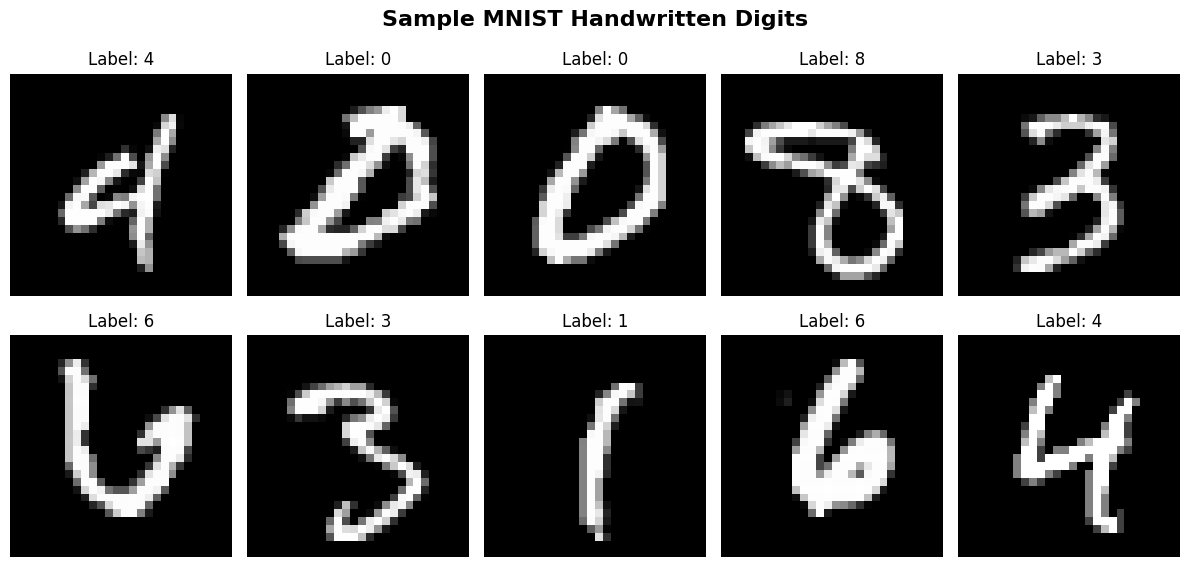

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f"Normalized training data shape: {X_train_normalized.shape}")
print(f"Categorical training labels shape: {y_train_categorical.shape}")

Normalized training data shape: (60000, 28, 28)
Categorical training labels shape: (60000, 10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)

        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
         tf.keras.layers.Dense(10, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),


        # Output layer for 10 classes with softmax activation
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the cnn model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


CNN Model created


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results
print("\\n=== MODEL PERFORMANCE COMPARISON ===")
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f} ({mlp_test_accuracy*100:.2f}%)")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.2f}%)")
print(f"Accuracy Improvement: {(cnn_test_accuracy - mlp_test_accuracy)*100:.2f}%")


\n=== MODEL PERFORMANCE COMPARISON ===
MLP Test Accuracy: 0.9738 (97.38%)
CNN Test Accuracy: 0.9901 (99.01%)
Accuracy Improvement: 1.63%


Performance comparison visualization

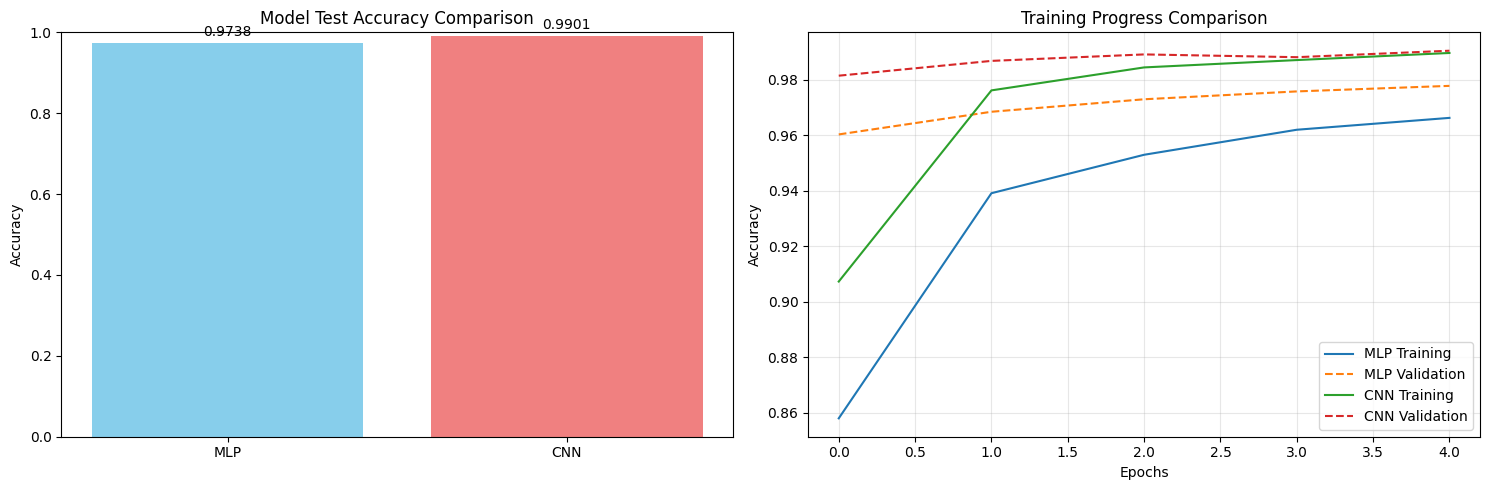

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart for final accuracy comparison
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]
bars = ax1.bar(models, accuracies, color=['skyblue', 'lightcoral'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Test Accuracy Comparison')
ax1.set_ylim(0, 1)
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom')
# Training progress comparison
ax2.plot(mlp_history.history['accuracy'], label='MLP Training', linestyle='-')
ax2.plot(mlp_history.history['val_accuracy'], label='MLP Validation', linestyle='--')
ax2.plot(cnn_history.history['accuracy'], label='CNN Training', linestyle='-')
ax2.plot(cnn_history.history['val_accuracy'], label='CNN Validation', linestyle='--')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Progress Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

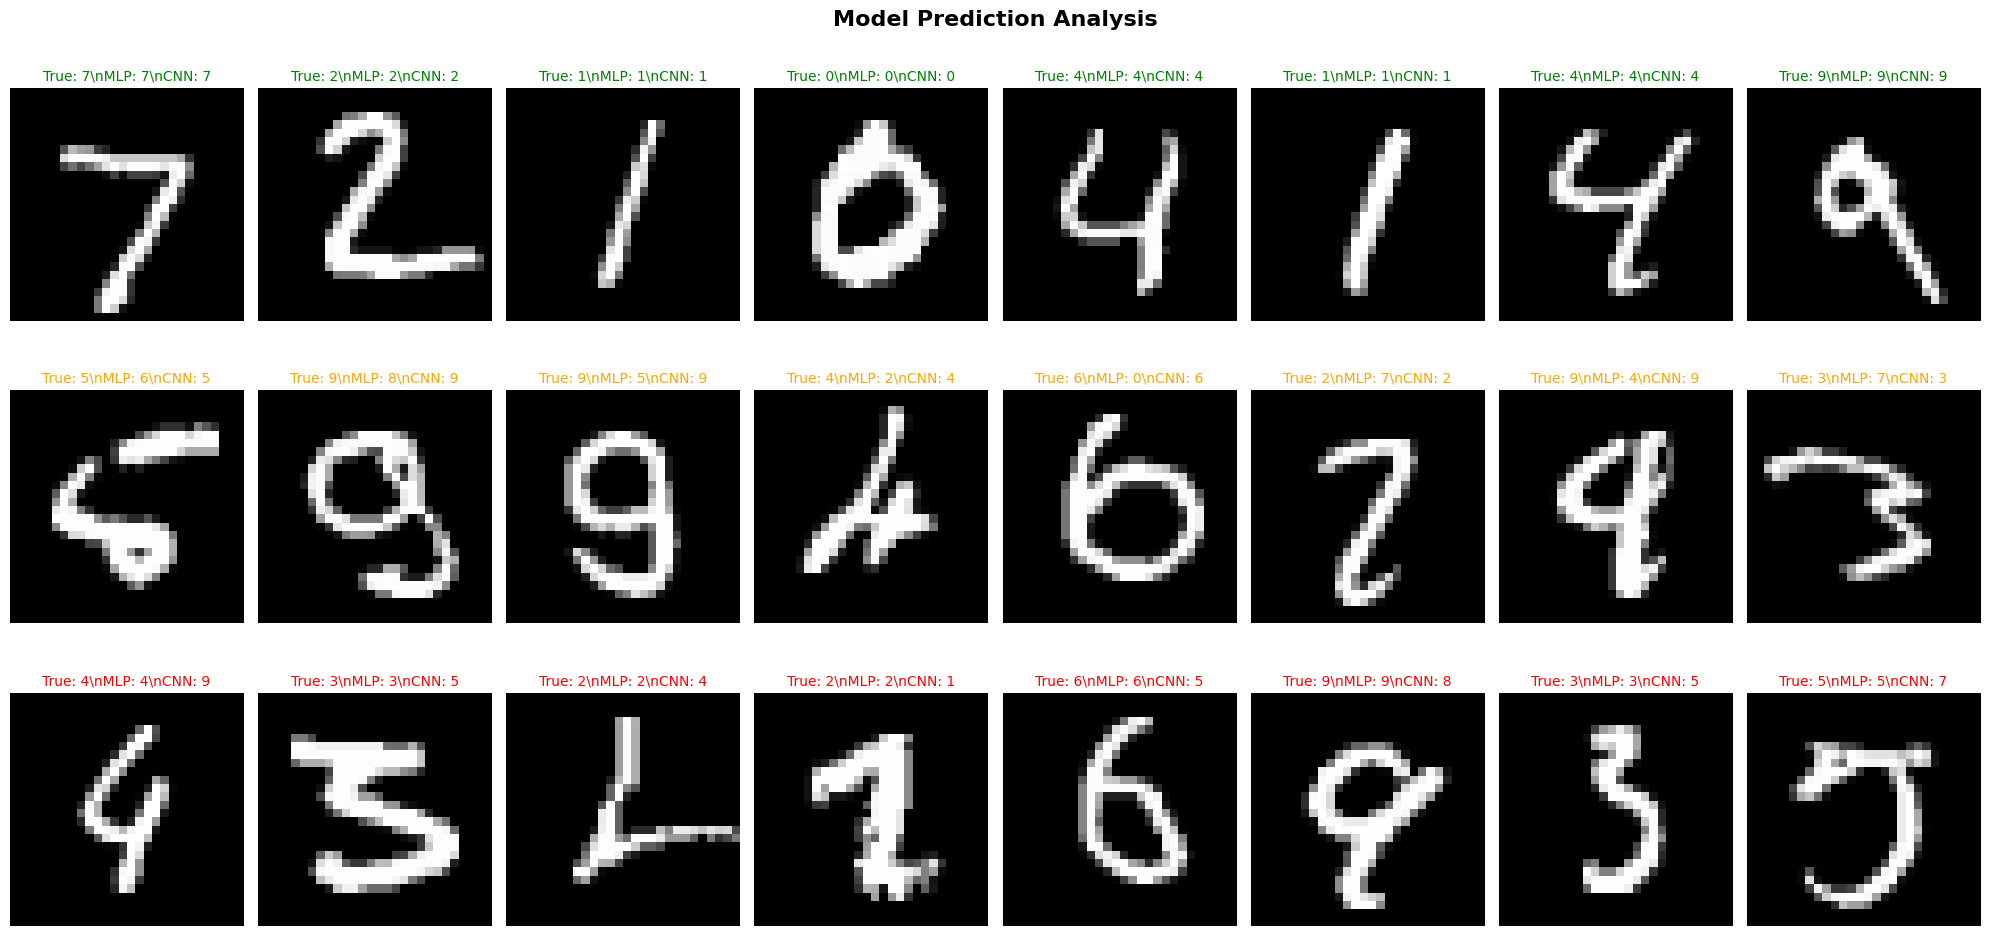

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(20, 10))
fig.suptitle('Model Prediction Analysis', fontsize=16, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

for i in range(8):
    # Row 1: Both models correct
    if i < len(both_correct_indices):
        idx = both_correct_indices[i]
        axes[0, i].imshow(X_test[idx], cmap='gray')
        axes[0, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                           fontsize=10, color='green')
        axes[0, i].axis('off')

    # Row 2: CNN correct, MLP wrong
    if i < len(cnn_correct_mlp_wrong_indices):
        idx = cnn_correct_mlp_wrong_indices[i]
        axes[1, i].imshow(X_test[idx], cmap='gray')
        axes[1, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                           fontsize=10, color='orange')
        axes[1, i].axis('off')

    # Row 3: MLP correct, CNN wrong
    if i < len(mlp_correct_cnn_wrong_indices):
        idx = mlp_correct_cnn_wrong_indices[i]
        axes[2, i].imshow(X_test[idx], cmap='gray')
        axes[2, i].set_title(f'True: {y_test[idx]}\\nMLP: {mlp_predicted_classes[idx]}\\nCNN: {cnn_predicted_classes[idx]}',
                           fontsize=10, color='red')
        axes[2, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Both Correct', rotation=90, size='large', fontweight='bold')
axes[1, 0].set_ylabel('CNN✓ MLP✗', rotation=90, size='large', fontweight='bold')
axes[2, 0].set_ylabel('MLP✓ CNN✗', rotation=90, size='large', fontweight='bold')

plt.tight_layout()
plt.show()


## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

1. Which model performed better and why?
The CNN model performed better. CNNs are specifically designed for image data as they can capture spatial hierarchies and local patterns through convolutional layers, while MLPs treat pixels as independent features without considering their spatial relationships.

2. How do the training curves compare between the two models?
The CNN typically shows faster convergence and higher validation accuracy during training. Both models show improving accuracy over epochs, but CNN generally achieves better final performance due to its architectural advantages for image data.

3. What does the accuracy improvement percentage tell us?
The accuracy improvement percentage quantifies how much better the CNN performs compared to the MLP. Even small improvements (e.g., 1-2%) can be significant in image classification tasks and demonstrate the effectiveness of convolutional operations.

4. Why didn't we need many epochs for good results?
print("MNIST is a relatively simple dataset with clean, centered digits and consistent formatting. The patterns are well-defined, and both models can learn the essential features quickly. Additionally, the large dataset size (60,000 training samples) provides sufficient examples for efficient learning.

5. What would happen with more complex images?
With more complex images (like CIFAR-10 or real-world photos), the performance gap between CNN and MLP would widen significantly. CNNs would maintain good performance through their ability to learn hierarchical features, while MLPs would struggle with the increased complexity, spatial variations, and noise in natural images.